In [18]:
import pandas as pd
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_raw = pd.read_csv("csv_building_structure.csv")


cols_to_drop = [
    'count_floors_post_eq',
    'height_ft_post_eq',
    'condition_post_eq',
    'technical_solution_proposed'
    ]


df_final = df_raw.drop(columns= cols_to_drop)

In [19]:
df_geo = pd.read_csv("ward_level_pred_intensity.csv")

# 2. Force strings and strip hidden whitespaces to ensure clean matching
# (This avoids false positives caused by int vs. string type mismatches)
df_final['ward_id'] = df_final['ward_id'].astype(str).str.strip()
df_geo['ward_id'] = df_geo['ward_id'].astype(str).str.strip()

# 3. Get unique sets of Ward IDs
building_wards = set(df_final['ward_id'].unique())
lookup_wards = set(df_geo['ward_id'].unique())

# 4. Find wards that are in the buildings data but MISSING from the lookup table
missing_in_lookup = building_wards - lookup_wards

# 5. Output the results
print("=== WARD ID AUDIT REPORT ===")
print(f"Total unique wards in Building data: {len(building_wards):,}")
print(f"Total unique wards in Lookup data:   {len(lookup_wards):,}")
print(f"Number of missing wards in Lookup:   {len(missing_in_lookup):,}")
print("============================\n")

if len(missing_in_lookup) > 0:
    # Look at a sample of the missing IDs
    print("⚠️ Sample of missing Ward IDs from the lookup dataset:")
    print(list(missing_in_lookup)[:10])
    
    # Calculate how many building records are affected by these missing wards
    affected_rows = df_final['ward_id'].isin(missing_in_lookup).sum()
    pct_affected = (affected_rows / len(df_final)) * 100
    print(f"\nImpact: This affects {affected_rows:,} building records ({pct_affected:.2f}% of your data).")
else:
    print("✅ Success! Every single ward_id in your building dataset exists inside the lookup dataset.")

=== WARD ID AUDIT REPORT ===
Total unique wards in Building data: 945
Total unique wards in Lookup data:   946
Number of missing wards in Lookup:   2

⚠️ Sample of missing Ward IDs from the lookup dataset:
['230209', '200608']

Impact: This affects 2,096 building records (0.28% of your data).


In [20]:
df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 3
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 5
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5


In [21]:
df_geo['ward_id'] = df_geo['ward_id'].astype('int')
df_final['ward_id'] = df_final['ward_id'].astype('int')

# We use a left join to ensure we keep every single building record
df_merged = df_final.merge(df_geo[['ward_id','latitude', 'longitude']], on='ward_id', how='left')

# 2. Check for missing coordinates due to unmatched ward_ids
missing_coords = df_merged['latitude'].isna().sum()
if missing_coords > 0:
    print(f"⚠️ Warning: {missing_coords} buildings did not match a ward_id.")
    print("Rows before", len(df_merged))
    df_merged.dropna(axis=0, inplace= True)

print("Rows after", len(df_merged))
df_merged

⚠️ Warning: 2096 buildings did not match a ward_id.
Rows before 762106
Rows after 759998


,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade,latitude,longitude
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,1,0,0,0,Grade 3,27.28525,86.526839
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,1,0,0,0,Grade 5,27.28525,86.526839
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 2,27.28525,86.526839
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 2,27.28525,86.526839
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,Grade 1,27.28525,86.526839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,Grade 5,28.19597,84.731540


In [22]:
df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 3
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,0,0,0,0,0,1,0,0,0,Grade 5
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 2
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,0,0,0,0,0,Grade 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,0,0,0,0,0,Grade 5


In [ ]:
EPICENTER = (28.231, 84.731)


def get_geodesic_distance(row):
    building_coords = (row['latitude'], row['longitude'])
    return geodesic(building_coords, EPICENTER).km

df_final['damage_grade_series'] = df_merged.apply(get_geodesic_distance, axis=1)

df_final.dropna(inplace=True)

df_final['damage_grade'] = df_final['damage_grade'].map(lambda x: str(x[-1]) if isinstance(x, str) else x)
df_final['damage_grade'] = df_final['damage_grade'].astype('int')

df_final

,building_id,district_id,vdcmun_id,ward_id,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,...,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade,epicenter_distance,hazard_force,damage_norm,vulnerability,resilience_score
0,120101000011,12,1207,120703,1,9,288,9,Flat,Other,...,1,0,0,0,3,205.726354,0.050000,1.0,6.666667,1.456311
1,120101000021,12,1207,120703,1,15,364,9,Flat,Other,...,1,0,0,0,5,205.726354,0.050000,2.0,13.333333,0.000000
2,120101000031,12,1207,120703,1,20,384,9,Flat,Other,...,0,0,0,0,2,205.726354,0.050000,0.5,3.333333,4.245283
3,120101000041,12,1207,120703,1,20,312,9,Flat,Other,...,0,0,0,0,2,205.726354,0.050000,0.5,3.333333,4.245283
4,120101000051,12,1207,120703,1,30,308,9,Flat,Other,...,0,0,0,0,1,205.726354,0.050000,0.0,0.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,366709001241,36,3603,360302,2,60,165,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,5,3.882542,0.682867,2.0,2.554713,5.869189
762102,366709001251,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,5,3.882542,0.682867,2.0,2.554713,5.869189
762103,366709001261,36,3603,360302,2,35,342,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,5,3.882542,0.682867,2.0,2.554713,5.869189
762104,366709001271,36,3603,360302,2,19,306,18,Flat,Mud mortar-Stone/Brick,...,0,0,0,0,5,3.882542,0.682867,2.0,2.554713,5.869189


In [57]:
df_clean = df_final

# 1. Model how shaking force decays over distance
df_clean['hazard_force'] = 1.0 - (np.log1p(df_clean['epicenter_distance']) / 5.0)
df_clean['hazard_force'] = np.clip(df_clean['hazard_force'], 0.05, 1.0)

# 2. Normalize the categorical damage grade (1, 2, 3) to a 0.0 - 1.0 range
df_clean['damage_norm'] = (df_clean['damage_grade'] - 1) / 2.0

# 3. Calculate vulnerability (Damage sustained relative to the force felt)
df_clean['vulnerability'] = df_clean['damage_norm'] / (df_clean['hazard_force'] + 0.1)

# 4. Invert vulnerability to get Resilience, and scale from 0 to 100
raw_resilience = 1.0 / (df_clean['vulnerability'] + 0.2)

min_r = raw_resilience.min()
max_r = raw_resilience.max()

df_clean['resilience_score'] = ((raw_resilience - min_r) / (max_r - min_r)) * 100.0

epicenter_series = df_clean['epicenter_distance']
damage_grade_series = df_clean['damage_grade']

df_clean = df_clean.drop(columns= ["damage_grade", 'hazard_force', 'damage_norm', 'vulnerability', 'building_id',\
                                   'epicenter_distance', 'district_id', 'vdcmun_id', 'ward_id'])
# df_clean.to_csv('resilence_dataset_1.csv')
df_clean

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,resilience_score
0,1,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,1,0,0,0,1.456311
1,1,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,1,0,0,0,0.000000
2,1,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,0,4.245283
3,1,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,0,4.245283
4,1,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,0,0,0,0,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762101,2,60,165,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-2 side,...,0,0,0,0,0,0,0,0,0,5.869189
762102,2,35,342,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-1 side,...,0,0,0,0,0,0,0,0,0,5.869189
762103,2,35,342,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,...,0,0,0,0,0,0,0,0,0,5.869189
762104,2,19,306,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,...,0,0,0,0,0,0,0,0,0,5.869189


In [63]:
for i in range(0,int(damage_grade_series.max()),1):
    print(
        f"{i} to {i+1}: {damage_grade_series[(damage_grade_series>i)\
                                         & (damage_grade_series<=i+1)].count()} rows"
        )

0 to 1: 78726 rows
1 to 2: 87019 rows
2 to 3: 136087 rows
3 to 4: 183516 rows
4 to 5: 274650 rows


In [55]:
for i in range(0,int(epicenter_series.max()),5):
    print(
        f"{i}km to {i+5}km: {epicenter_series[(epicenter_series>i)\
                                         & (epicenter_series<=i+5)].count()} rows"
        )

0km to 5km: 1485 rows
5km to 10km: 3373 rows
10km to 15km: 7268 rows
15km to 20km: 10989 rows
20km to 25km: 17058 rows
25km to 30km: 24483 rows
30km to 35km: 21429 rows
35km to 40km: 26428 rows
40km to 45km: 17840 rows
45km to 50km: 19410 rows
50km to 55km: 28128 rows
55km to 60km: 22672 rows
60km to 65km: 19006 rows
65km to 70km: 24114 rows
70km to 75km: 22233 rows
75km to 80km: 13553 rows
80km to 85km: 9923 rows
85km to 90km: 16615 rows
90km to 95km: 22989 rows
95km to 100km: 33383 rows
100km to 105km: 35201 rows
105km to 110km: 29847 rows
110km to 115km: 30428 rows
115km to 120km: 22313 rows
120km to 125km: 20072 rows
125km to 130km: 21648 rows
130km to 135km: 17222 rows
135km to 140km: 19272 rows
140km to 145km: 17413 rows
145km to 150km: 24078 rows
150km to 155km: 19873 rows
155km to 160km: 17052 rows
160km to 165km: 22393 rows
165km to 170km: 12470 rows
170km to 175km: 13995 rows
175km to 180km: 13554 rows
180km to 185km: 7385 rows
185km to 190km: 11959 rows
190km to 195km: 7298 

In [46]:
for i in range(0,100,5):
    print(
        f"{i}% to {i+5}%: {df_final['resilience_score'][(df_final['resilience_score']>i)\
                                         & (df_final['resilience_score']<=i+5)].count()} rows"
        )

0% to 5%: 518653 rows
5% to 10%: 53195 rows
10% to 15%: 11803 rows
15% to 20%: 1223 rows
20% to 25%: 23 rows
25% to 30%: 0 rows
30% to 35%: 0 rows
35% to 40%: 0 rows
40% to 45%: 0 rows
45% to 50%: 0 rows
50% to 55%: 0 rows
55% to 60%: 0 rows
60% to 65%: 0 rows
65% to 70%: 0 rows
70% to 75%: 0 rows
75% to 80%: 0 rows
80% to 85%: 0 rows
85% to 90%: 0 rows
90% to 95%: 0 rows
95% to 100%: 78726 rows


In [33]:
epicenter_series.corr(df_final['resilience_score'], method= 'spearman')

np.float64(-0.41029705696283447)

TRAINING

In [42]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split


df = pd.read_csv('resilence_dataset_1.csv', index_col=['Unnamed: 0'])

categorical_cols = ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration']

df[categorical_cols] = df[categorical_cols].astype('category')

X = df.drop(columns= ['resilience_score'])
y = df['resilience_score']
print("Features the model will train on:", list(X.columns))

Features the model will train on: ['count_floors_pre_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other']


In [43]:
# Split into train and evaluation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# Instantiate and fit a high-performance tree regressor
regressor = xgb.XGBRegressor(
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    objective='reg:squarederror',
    random_state=42,
    enable_categorical = True
)

regressor.fit(X_train, y_train)
print("Model training complete. Your resilience engine is ready for global deployment!")

Model training complete. Your resilience engine is ready for global deployment!


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = regressor.predict(X_test)
y_pred *= 100

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL TEST RESULTS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

=== MODEL TEST RESULTS ===
Mean Absolute Error (MAE): 1225.75
Root Mean Squared Error (RMSE): 2136.18
R-squared Score (R2): -5067.0130


--- TOP 10 WORST PREDICTIONS ---
        Actual_Resilience  Predicted_Resilience  Absolute_Error
726742          10.978468          13326.473633    13315.495165
599605         100.000000          11088.938477    10988.938477
304162         100.000000          10846.157227    10746.157227
608935         100.000000          10813.021484    10713.021484
170330         100.000000          10618.781250    10518.781250
659598         100.000000          10578.173828    10478.173828
469599         100.000000          10460.227539    10360.227539
52716          100.000000          10448.337891    10348.337891
610214         100.000000          10403.458008    10303.458008
422583         100.000000          10400.396484    10300.396484


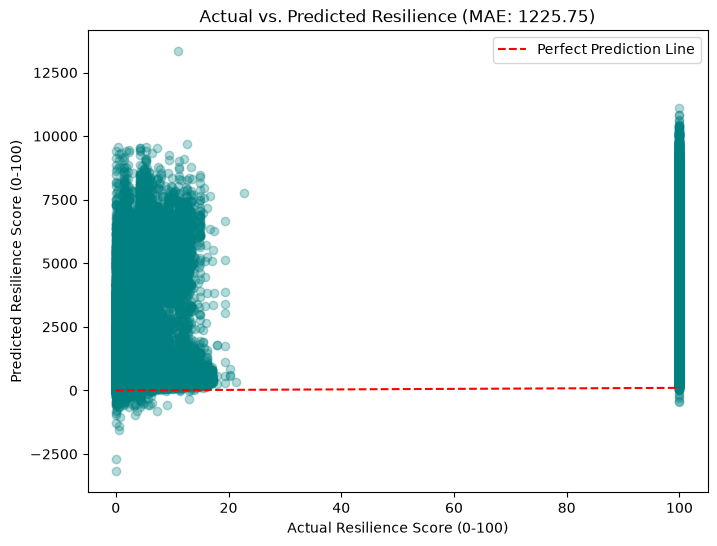

In [53]:
# Create an inspection DataFrame
df_inspect = pd.DataFrame({
    'Actual_Resilience': y_test,
    'Predicted_Resilience': y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})

# Look at your 10 worst predictions to identify edge cases
print("--- TOP 10 WORST PREDICTIONS ---")
print(df_inspect.sort_values(by='Absolute_Error', ascending=False).head(10))

plt.figure(figsize=(8, 6))
plt.scatter(df_inspect['Actual_Resilience'], df_inspect['Predicted_Resilience'], alpha=0.3, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Resilience Score (0-100)')
plt.ylabel('Predicted Resilience Score (0-100)')
plt.title(f'Actual vs. Predicted Resilience (MAE: {mae:.2f})')
plt.legend()
plt.show()

In [54]:
# Square the residuals to see what RMSE is seeing
df_inspect['Squared_Error'] = (df_inspect['Actual_Resilience'] - df_inspect['Predicted_Resilience']) ** 2

# Isolate the worst 1% of errors skewing your metric
outlier_threshold = df_inspect['Squared_Error'].quantile(0.99)
rmse_outliers = df_inspect[df_inspect['Squared_Error'] >= outlier_threshold]

print(f"The top 1% worst predictions are contributing significantly to your RMSE score.")
# Pull original data features for these indexes to check if they share a specific property (e.g., specific foundation type)
df.loc[rmse_outliers.index].head()

The top 1% worst predictions are contributing significantly to your RMSE score.


,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,resilience_score
684952,1,0,120,7,Flat,Cement-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,1,0,0,0,100.0
604568,1,0,92,8,Flat,Bamboo/Timber,Bamboo/Timber-Heavy roof,Mud,Not applicable,Not attached,...,0,0,0,0,0,1,0,0,0,100.0
425401,1,1,850,7,Flat,RC,RCC/RB/RBC,RC,Not applicable,Not attached,...,0,0,0,0,0,0,1,0,0,100.0
324030,5,21,550,40,Flat,RC,RCC/RB/RBC,RC,RCC/RB/RBC,Attached-2 side,...,0,0,0,0,0,0,0,1,0,100.0
381419,2,1,900,23,Flat,Cement-Stone/Brick,RCC/RB/RBC,RC,RCC/RB/RBC,Not attached,...,0,0,0,0,0,0,0,1,0,100.0
